# Crop Yield Prediction – ML Experiment

**Objective:** Train a regression model to predict crop yield based on features like crop type, area, season, rainfall, temperature, humidity, and soil properties.

**Dataset:** Synthetic Indian agriculture dataset (mimicking Kaggle crop-yield datasets with features: crop, state, season, area, rainfall, temperature, humidity, soil pH, N, P, K).

**Models:** Linear Regression, Random Forest Regressor

**Metric:** MAE, RMSE, R²

In [1]:
# Cell 1: Install & Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Cell 2: Generate Synthetic Indian Crop Yield Dataset
# In production, replace this with a real Kaggle dataset
np.random.seed(42)

n_samples = 5000

crops = ['Rice', 'Wheat', 'Maize', 'Sugarcane', 'Cotton', 'Soybean', 'Groundnut']
states = ['Andhra Pradesh', 'Punjab', 'Uttar Pradesh', 'Maharashtra', 'Karnataka',
          'Tamil Nadu', 'Madhya Pradesh', 'Rajasthan', 'Gujarat', 'West Bengal']
seasons = ['Kharif', 'Rabi', 'Zaid']
soil_types = ['Alluvial', 'Black', 'Red', 'Laterite', 'Sandy', 'Clay']

# Base yields per crop (tonnes/hectare)
base_yields = {
    'Rice': 3.5, 'Wheat': 3.0, 'Maize': 2.8, 'Sugarcane': 70.0,
    'Cotton': 1.5, 'Soybean': 1.2, 'Groundnut': 1.8
}

data = []
for _ in range(n_samples):
    crop = np.random.choice(crops)
    state = np.random.choice(states)
    season = np.random.choice(seasons)
    soil = np.random.choice(soil_types)
    area = np.round(np.random.uniform(0.5, 10.0), 2)
    rainfall = np.round(np.random.uniform(200, 2500), 1)
    temp_avg = np.round(np.random.uniform(15, 40), 1)
    humidity = np.round(np.random.uniform(30, 95), 1)
    soil_ph = np.round(np.random.uniform(4.5, 9.0), 1)
    nitrogen = np.round(np.random.uniform(10, 140), 1)
    phosphorus = np.round(np.random.uniform(5, 80), 1)
    potassium = np.round(np.random.uniform(5, 100), 1)

    # Simulate yield with some logic
    base = base_yields[crop]
    # Rainfall effect (optimal range varies by crop)
    rain_factor = 1.0 + 0.1 * np.clip((rainfall - 500) / 1000, -0.3, 0.3)
    # Temperature effect
    temp_factor = 1.0 - 0.01 * abs(temp_avg - 27)
    # Soil pH effect (optimal ~6.5)
    ph_factor = 1.0 - 0.05 * abs(soil_ph - 6.5)
    # NPK effect
    npk_factor = 1.0 + 0.002 * (nitrogen + phosphorus + potassium) / 3
    # Humidity effect
    hum_factor = 1.0 + 0.001 * (humidity - 60)

    yield_val = base * rain_factor * temp_factor * ph_factor * npk_factor * hum_factor
    yield_val *= np.random.uniform(0.85, 1.15)  # noise
    yield_val = np.round(max(0.1, yield_val), 2)

    data.append({
        'crop_type': crop, 'state': state, 'season': season, 'soil_type': soil,
        'area_ha': area, 'rainfall_mm': rainfall, 'temp_avg_c': temp_avg,
        'humidity_pct': humidity, 'soil_ph': soil_ph,
        'nitrogen_kg': nitrogen, 'phosphorus_kg': phosphorus, 'potassium_kg': potassium,
        'yield_tonnes_per_ha': yield_val
    })

df = pd.DataFrame(data)
print(f'Dataset shape: {df.shape}')
df.head(10)

Dataset shape: (5000, 13)


,crop_type,state,season,soil_type,area_ha,rainfall_mm,temp_avg_c,humidity_pct,soil_ph,nitrogen_kg,phosphorus_kg,potassium_kg,yield_tonnes_per_ha
0,Groundnut,Maharashtra,Kharif,Red,7.91,1572.8,26.1,36.5,6.6,53.4,15.7,66.8,1.69
1,Sugarcane,Tamil Nadu,Rabi,Laterite,2.24,899.8,28.1,58.1,5.8,89.5,15.5,32.8,71.98
2,Soybean,Uttar Pradesh,Zaid,Laterite,6.13,306.8,30.2,41.1,4.8,133.4,77.4,81.8,1.15
3,Cotton,Punjab,Zaid,Laterite,1.66,1338.9,15.9,89.1,5.7,96.1,28.4,54.4,1.54
4,Soybean,Punjab,Rabi,Laterite,9.43,2258.1,29.9,89.9,4.9,35.5,8.4,35.9,1.16
5,Wheat,Karnataka,Rabi,Alluvial,3.17,1448.2,18.5,82.1,4.8,138.3,62.9,23.9,2.59
6,Maize,Uttar Pradesh,Kharif,Red,8.01,1593.7,38.2,72.3,8.6,120.5,38.7,14.1,2.49
7,Soybean,Rajasthan,Kharif,Red,6.12,831.9,29.0,54.9,8.9,120.4,59.1,27.4,1.12
8,Maize,Gujarat,Zaid,Black,0.74,448.2,15.8,71.4,5.9,76.1,73.1,28.7,2.64
9,Maize,Maharashtra,Kharif,Red,7.10,2225.1,30.6,49.2,5.0,69.3,21.4,44.6,3.09


In [3]:
# Cell 3: Exploratory Data Analysis
print('=== Dataset Info ===')
print(df.describe())
print(f'\nNull values:\n{df.isnull().sum()}')
print(f'\nCrop distribution:\n{df["crop_type"].value_counts()}')

=== Dataset Info ===
           area_ha  rainfall_mm   temp_avg_c  humidity_pct      soil_ph  \
count  5000.000000  5000.000000  5000.000000   5000.000000  5000.000000   
mean      5.277256  1360.476540    27.352400     62.674680     6.743260   
std       2.726361   660.501249     7.270993     18.652197     1.303826   
min       0.500000   200.100000    15.000000     30.000000     4.500000   
25%       2.910000   789.175000    21.075000     46.875000     5.600000   
50%       5.280000  1350.800000    27.300000     62.800000     6.700000   
75%       7.650000  1927.375000    33.800000     78.700000     7.900000   
max      10.000000  2499.700000    40.000000     95.000000     9.000000   

       nitrogen_kg  phosphorus_kg  potassium_kg  yield_tonnes_per_ha  
count  5000.000000    5000.000000   5000.000000          5000.000000  
mean     74.281360      41.576980     52.802880            12.584104  
std      37.594747      21.508639     27.054786            24.581565  
min      10.000000 

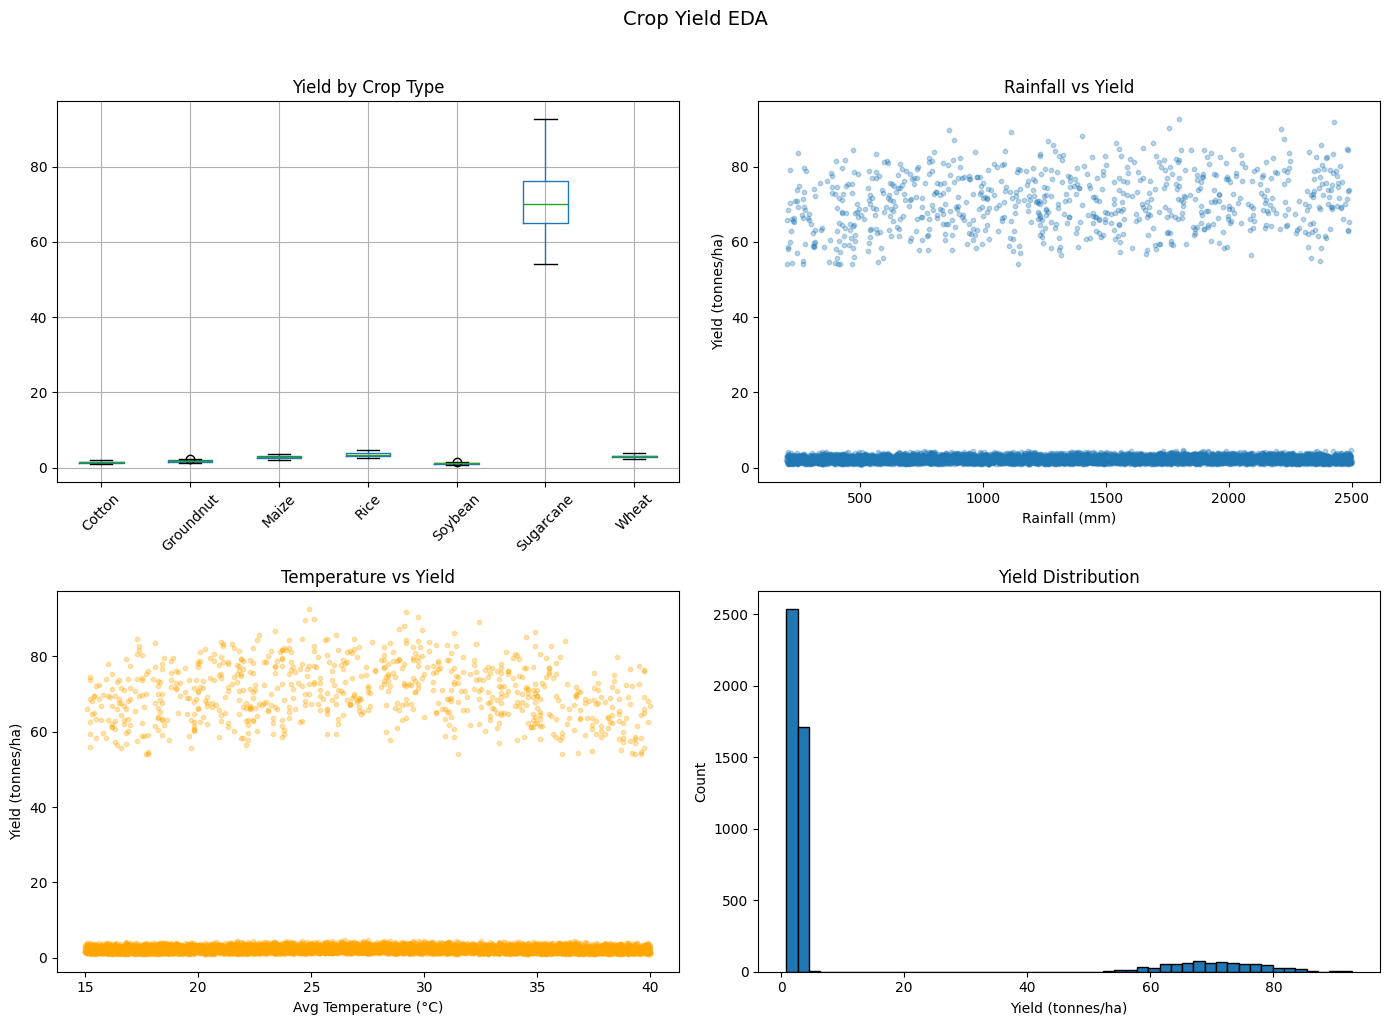

In [4]:
# Cell 4: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Yield distribution by crop
df.boxplot(column='yield_tonnes_per_ha', by='crop_type', ax=axes[0, 0], rot=45)
axes[0, 0].set_title('Yield by Crop Type')
axes[0, 0].set_xlabel('')

# Rainfall vs Yield
axes[0, 1].scatter(df['rainfall_mm'], df['yield_tonnes_per_ha'], alpha=0.3, s=10)
axes[0, 1].set_xlabel('Rainfall (mm)')
axes[0, 1].set_ylabel('Yield (tonnes/ha)')
axes[0, 1].set_title('Rainfall vs Yield')

# Temperature vs Yield
axes[1, 0].scatter(df['temp_avg_c'], df['yield_tonnes_per_ha'], alpha=0.3, s=10, c='orange')
axes[1, 0].set_xlabel('Avg Temperature (°C)')
axes[1, 0].set_ylabel('Yield (tonnes/ha)')
axes[1, 0].set_title('Temperature vs Yield')

# Yield distribution
axes[1, 1].hist(df['yield_tonnes_per_ha'], bins=50, edgecolor='black')
axes[1, 1].set_xlabel('Yield (tonnes/ha)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Yield Distribution')

plt.suptitle('Crop Yield EDA', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

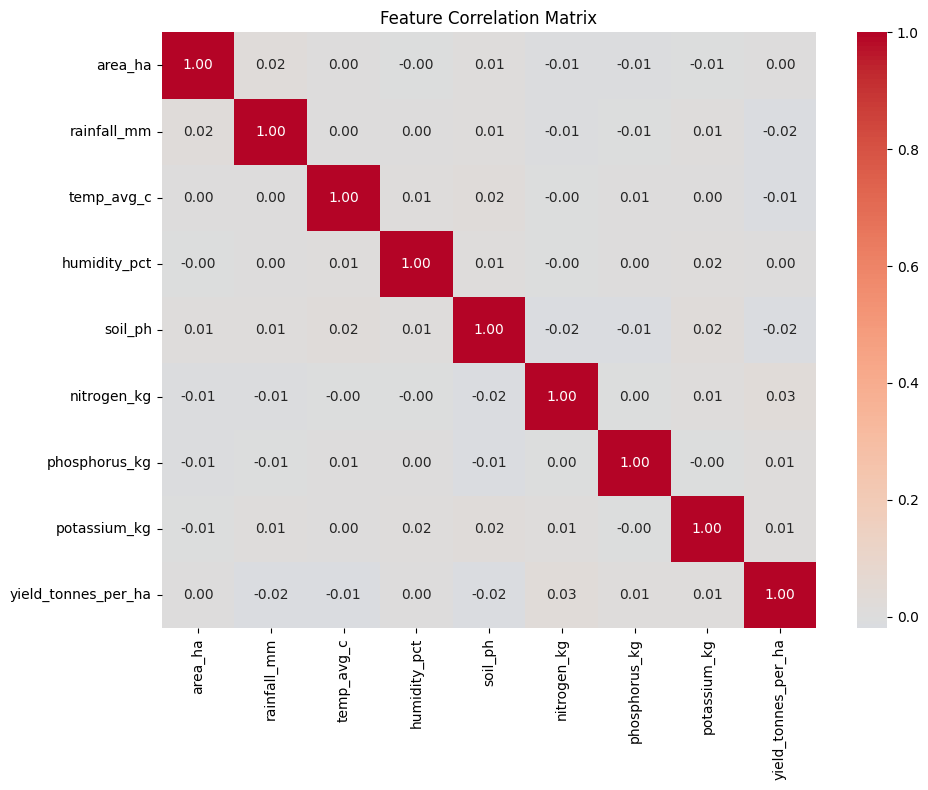

In [5]:
# Cell 5: Feature Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [6]:
# Cell 6: Feature Engineering & Encoding

# Label encode categorical features
label_encoders = {}
categorical_cols = ['crop_type', 'state', 'season', 'soil_type']

df_encoded = df.copy()
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print(f'\nEncoded dataset shape: {df_encoded.shape}')
df_encoded.head()

crop_type: {np.str_('Cotton'): np.int64(0), np.str_('Groundnut'): np.int64(1), np.str_('Maize'): np.int64(2), np.str_('Rice'): np.int64(3), np.str_('Soybean'): np.int64(4), np.str_('Sugarcane'): np.int64(5), np.str_('Wheat'): np.int64(6)}
state: {np.str_('Andhra Pradesh'): np.int64(0), np.str_('Gujarat'): np.int64(1), np.str_('Karnataka'): np.int64(2), np.str_('Madhya Pradesh'): np.int64(3), np.str_('Maharashtra'): np.int64(4), np.str_('Punjab'): np.int64(5), np.str_('Rajasthan'): np.int64(6), np.str_('Tamil Nadu'): np.int64(7), np.str_('Uttar Pradesh'): np.int64(8), np.str_('West Bengal'): np.int64(9)}
season: {np.str_('Kharif'): np.int64(0), np.str_('Rabi'): np.int64(1), np.str_('Zaid'): np.int64(2)}
soil_type: {np.str_('Alluvial'): np.int64(0), np.str_('Black'): np.int64(1), np.str_('Clay'): np.int64(2), np.str_('Laterite'): np.int64(3), np.str_('Red'): np.int64(4), np.str_('Sandy'): np.int64(5)}

Encoded dataset shape: (5000, 13)


,crop_type,state,season,soil_type,area_ha,rainfall_mm,temp_avg_c,humidity_pct,soil_ph,nitrogen_kg,phosphorus_kg,potassium_kg,yield_tonnes_per_ha
0,1,4,0,4,7.91,1572.8,26.1,36.5,6.6,53.4,15.7,66.8,1.69
1,5,7,1,3,2.24,899.8,28.1,58.1,5.8,89.5,15.5,32.8,71.98
2,4,8,2,3,6.13,306.8,30.2,41.1,4.8,133.4,77.4,81.8,1.15
3,0,5,2,3,1.66,1338.9,15.9,89.1,5.7,96.1,28.4,54.4,1.54
4,4,5,1,3,9.43,2258.1,29.9,89.9,4.9,35.5,8.4,35.9,1.16


In [7]:
# Cell 7: Train/Test Split

feature_cols = ['crop_type', 'state', 'season', 'soil_type', 'area_ha',
                'rainfall_mm', 'temp_avg_c', 'humidity_pct', 'soil_ph',
                'nitrogen_kg', 'phosphorus_kg', 'potassium_kg']

X = df_encoded[feature_cols]
y = df_encoded['yield_tonnes_per_ha']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Features:     {feature_cols}')

Training set: 4000 samples
Test set:     1000 samples
Features:     ['crop_type', 'state', 'season', 'soil_type', 'area_ha', 'rainfall_mm', 'temp_avg_c', 'humidity_pct', 'soil_ph', 'nitrogen_kg', 'phosphorus_kg', 'potassium_kg']


In [8]:
# Cell 8: Model 1 – Linear Regression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print('=== Linear Regression ===' )
print(f'MAE:  {lr_mae:.4f}')
print(f'RMSE: {lr_rmse:.4f}')
print(f'R²:   {lr_r2:.4f}')

=== Linear Regression ===
MAE:  16.0849
RMSE: 22.9016
R²:   0.1951


In [9]:
# Cell 9: Model 2 – Random Forest Regressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print('=== Random Forest Regressor ===')
print(f'MAE:  {rf_mae:.4f}')
print(f'RMSE: {rf_rmse:.4f}')
print(f'R²:   {rf_r2:.4f}')

=== Random Forest Regressor ===
MAE:  1.1909
RMSE: 2.9565
R²:   0.9866


In [10]:
# Cell 10: Model Comparison

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R²': [lr_r2, rf_r2]
})
print(results.to_string(index=False))

# Determine best model
best_model_name = 'Random Forest' if rf_r2 > lr_r2 else 'Linear Regression'
best_model = rf_model if rf_r2 > lr_r2 else lr_model
best_pred = y_pred_rf if rf_r2 > lr_r2 else y_pred_lr
print(f'\n✓ Best model: {best_model_name}')

            Model       MAE      RMSE       R²
Linear Regression 16.084856 22.901616 0.195149
    Random Forest  1.190882  2.956471 0.986587

✓ Best model: Random Forest


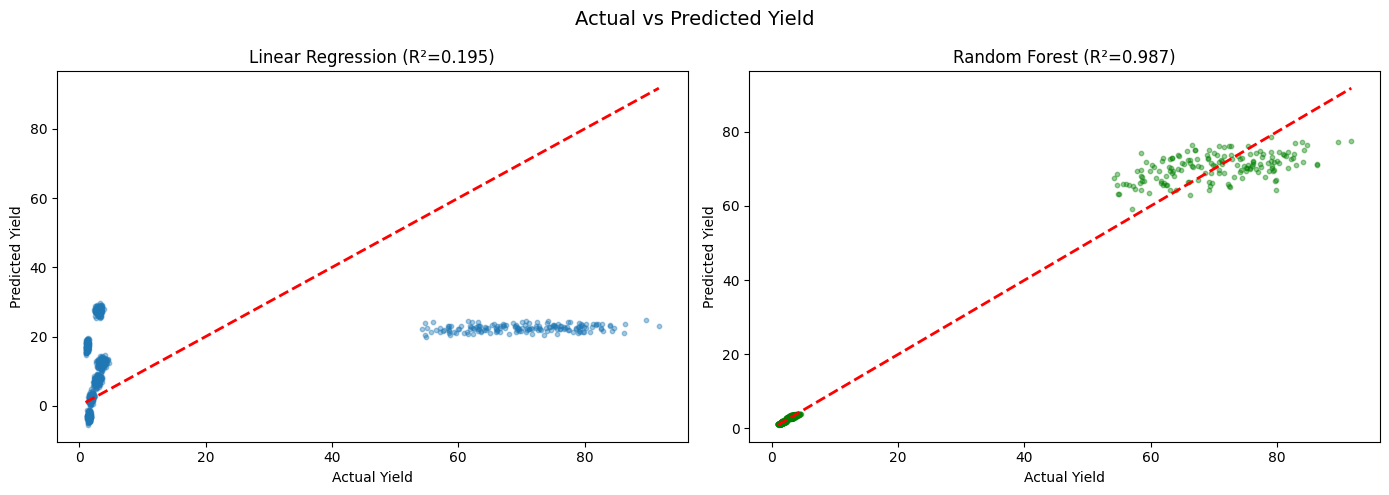

In [11]:
# Cell 11: Actual vs Predicted Plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_lr, alpha=0.4, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Yield')
axes[0].set_ylabel('Predicted Yield')
axes[0].set_title(f'Linear Regression (R²={lr_r2:.3f})')

axes[1].scatter(y_test, y_pred_rf, alpha=0.4, s=10, c='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Yield')
axes[1].set_ylabel('Predicted Yield')
axes[1].set_title(f'Random Forest (R²={rf_r2:.3f})')

plt.suptitle('Actual vs Predicted Yield', fontsize=14)
plt.tight_layout()
plt.show()

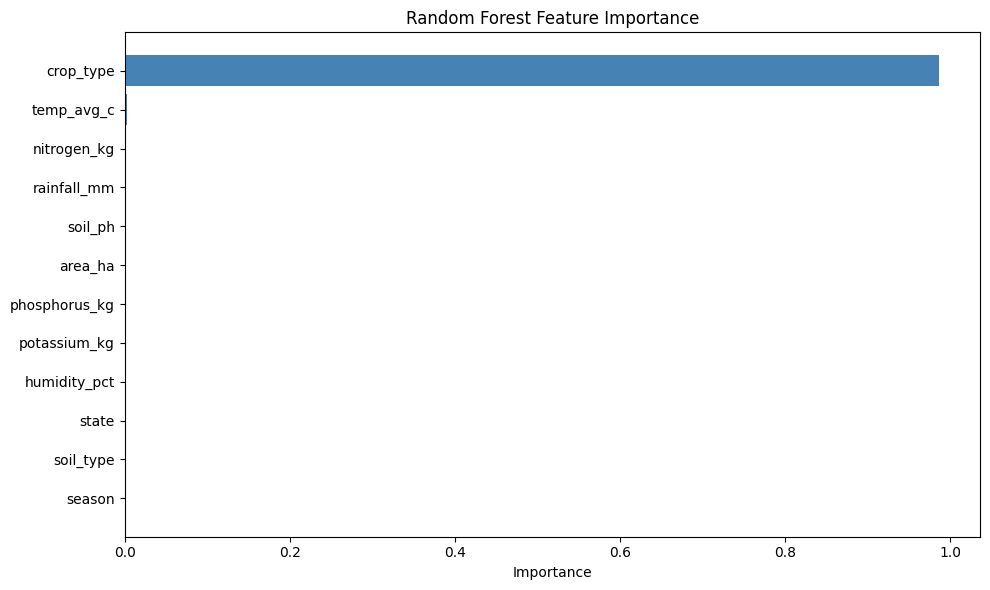

      Feature  Importance
    crop_type    0.987017
   temp_avg_c    0.002686
  nitrogen_kg    0.001839
  rainfall_mm    0.001461
      soil_ph    0.001366
      area_ha    0.001188
phosphorus_kg    0.001165
 potassium_kg    0.001079
 humidity_pct    0.000991
        state    0.000594
    soil_type    0.000424
       season    0.000191


In [12]:
# Cell 12: Feature Importance (Random Forest)

importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

print(feat_imp.sort_values('Importance', ascending=False).to_string(index=False))

In [13]:
# Cell 13: Export Model, Scaler, and Encoders

import os
model_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'YEILD planner', 'ml-service', 'model')
# Use a simpler relative path
model_dir = '../ml-service/model'
os.makedirs(model_dir, exist_ok=True)

# Save the best model
joblib.dump(best_model, os.path.join(model_dir, 'yield_model.pkl'))
print(f'Saved model: yield_model.pkl')

# Save scaler
joblib.dump(scaler, os.path.join(model_dir, 'scaler.pkl'))
print(f'Saved scaler: scaler.pkl')

# Save label encoders
joblib.dump(label_encoders, os.path.join(model_dir, 'label_encoders.pkl'))
print(f'Saved label_encoders: label_encoders.pkl')

# Save feature order and metadata
model_metadata = {
    'feature_order': feature_cols,
    'categorical_features': categorical_cols,
    'numeric_features': [c for c in feature_cols if c not in categorical_cols],
    'model_type': best_model_name,
    'label_encoder_classes': {col: list(le.classes_) for col, le in label_encoders.items()},
    'metrics': {
        'mae': float(rf_mae if best_model_name == 'Random Forest' else lr_mae),
        'rmse': float(rf_rmse if best_model_name == 'Random Forest' else lr_rmse),
        'r2': float(rf_r2 if best_model_name == 'Random Forest' else lr_r2)
    },
    'model_version': 'v1.0'
}

with open(os.path.join(model_dir, 'model_metadata.json'), 'w') as f:
    json.dump(model_metadata, f, indent=2)
print(f'Saved metadata: model_metadata.json')
print(f'\nModel directory: {os.path.abspath(model_dir)}')
print(f'Feature order: {feature_cols}')

Saved model: yield_model.pkl
Saved scaler: scaler.pkl
Saved label_encoders: label_encoders.pkl
Saved metadata: model_metadata.json

Model directory: c:\PROJECTS\YEILD planner\ml-service\model
Feature order: ['crop_type', 'state', 'season', 'soil_type', 'area_ha', 'rainfall_mm', 'temp_avg_c', 'humidity_pct', 'soil_ph', 'nitrogen_kg', 'phosphorus_kg', 'potassium_kg']


In [14]:
# Cell 14: Quick Test – Predict with Saved Model

# Simulate a prediction request
test_input = {
    'crop_type': 'Rice',
    'state': 'Andhra Pradesh',
    'season': 'Kharif',
    'soil_type': 'Alluvial',
    'area_ha': 2.0,
    'rainfall_mm': 850.0,
    'temp_avg_c': 29.5,
    'humidity_pct': 75.0,
    'soil_ph': 6.8,
    'nitrogen_kg': 80.0,
    'phosphorus_kg': 40.0,
    'potassium_kg': 50.0
}

# Encode categoricals
encoded = test_input.copy()
for col in categorical_cols:
    le = label_encoders[col]
    encoded[col] = le.transform([test_input[col]])[0]

# Create feature vector in correct order
feature_vector = np.array([[encoded[f] for f in feature_cols]])
feature_vector_scaled = scaler.transform(feature_vector)

predicted_yield = best_model.predict(feature_vector_scaled)[0]
print(f'Input: {test_input}')
print(f'\nPredicted Yield: {predicted_yield:.2f} tonnes/hectare')
print(f'Model: {best_model_name} (v1.0)')

Input: {'crop_type': 'Rice', 'state': 'Andhra Pradesh', 'season': 'Kharif', 'soil_type': 'Alluvial', 'area_ha': 2.0, 'rainfall_mm': 850.0, 'temp_avg_c': 29.5, 'humidity_pct': 75.0, 'soil_ph': 6.8, 'nitrogen_kg': 80.0, 'phosphorus_kg': 40.0, 'potassium_kg': 50.0}

Predicted Yield: 3.69 tonnes/hectare
Model: Random Forest (v1.0)
